In [73]:
# Import Required Packages
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
first_name = "Benjamin"
last_name = "Branta"

In [ ]:
# Subtask 1.1: Download and read the file
salary_df = pd.read_excel("2021_Salary Statistics by Employee.xlsx")

In [3]:
salary_df.head()

,Name,Sub Department,Empl Class Code,Pay Basis,Job FTE,Years in Job,Job Title,Working Title,Comp Rate,Annual Salary
0,"BECKER, JANE A",ACADEMIC AFFAIRS,CP,H,1.0,7.704110,UNIV EXEC STAFF ASST,UNIV EXEC STAFF ASST,27.64,57491.2
1,"CASE, JASMINE LEAH",ACADEMIC AFFAIRS,AS,A,1.0,0.027397,ADMIN PROGRAM SPEC,SPEC-STUDENT RET/ ENGAGE LRN,62000.00,62000.0
2,"ROZOWSKI, CASEY MATTHEW",ACADEMIC AFFAIRS,LI,A,1.0,1.120548,"DIR, UNSPECIFIED (10)","DIR MGMT, ANALYTICS, REPORTING",100000.00,100000.0
3,"JAMELSKE, STEPHANIE PASCOE",ACADEMIC AFFAIRS,LI,A,1.0,16.668493,ADMIN OFFICER/M,BUDGET OFFICER,100444.00,100444.0
4,"HOFFMAN, MARY F",ACADEMIC AFFAIRS,LI,A,1.0,1.205479,ASSOC VICE CHANCELLOR,INTERIM ASSOC VICE CHANCELLOR,144840.00,144840.0


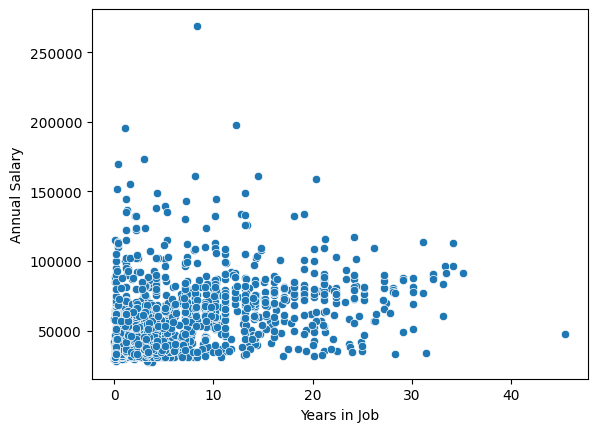

In [17]:
# Subtask 1.2: Salary vs years in job
# Make a scatterplot of salary (y) vs years in job (x), for the entire dataset. 
# Have your code automatically save this figure as LAST_FIRST_assign6b_task1-2.png
#  (as always, replace "LAST_FIRST" with your own last and first name separated by a _).
sns.scatterplot(salary_df, x='Years in Job', y='Annual Salary')
plt.savefig(f'{last_name}_{first_name}_assign6b_task1-2.png', dpi=300, bbox_inches="tight")

<Axes: xlabel='Years in Job', ylabel='Annual Salary'>

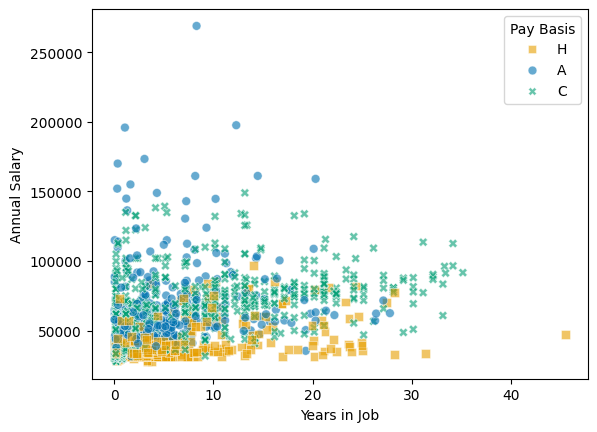

In [ ]:
# Subtask 1.3: Add a third data aspect to a scatterplot
sns.scatterplot(
    data=salary_df,
    x="Years in Job",
    y="Annual Salary",
    hue="Pay Basis",
    style="Pay Basis",
    palette={
        "A": "#0072B2",  # Blue
        "H": "#E69F00",  # Orange
        "C": "#009E73"   # Bluish Green
    },
    markers={
        "A": "o",
        "H": "s",
        "C": "X"
    },
    s=40,        # marker size
    alpha=0.6
)
plt.savefig(f'{last_name}_{first_name}_assign6b_task1-3.png', dpi=300, bbox_inches="tight")

<Axes: xlabel='Pay Basis', ylabel='Annual Salary'>

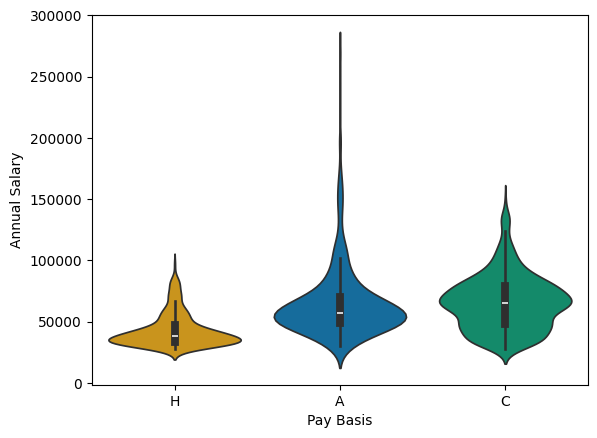

In [ ]:
# Subtask 1.4: Violin plots of salaries
sns.violinplot(
    data=salary_df,
    x="Pay Basis",
    y="Annual Salary",
    hue="Pay Basis",
    palette={
        "A": "#0072B2",  # Blue
        "H": "#E69F00",  # Orange
        "C": "#009E73"   # Bluish Green
    },
)
plt.savefig(f'{last_name}_{first_name}_assign6b_task1-4-1.png', dpi=300, bbox_inches="tight")

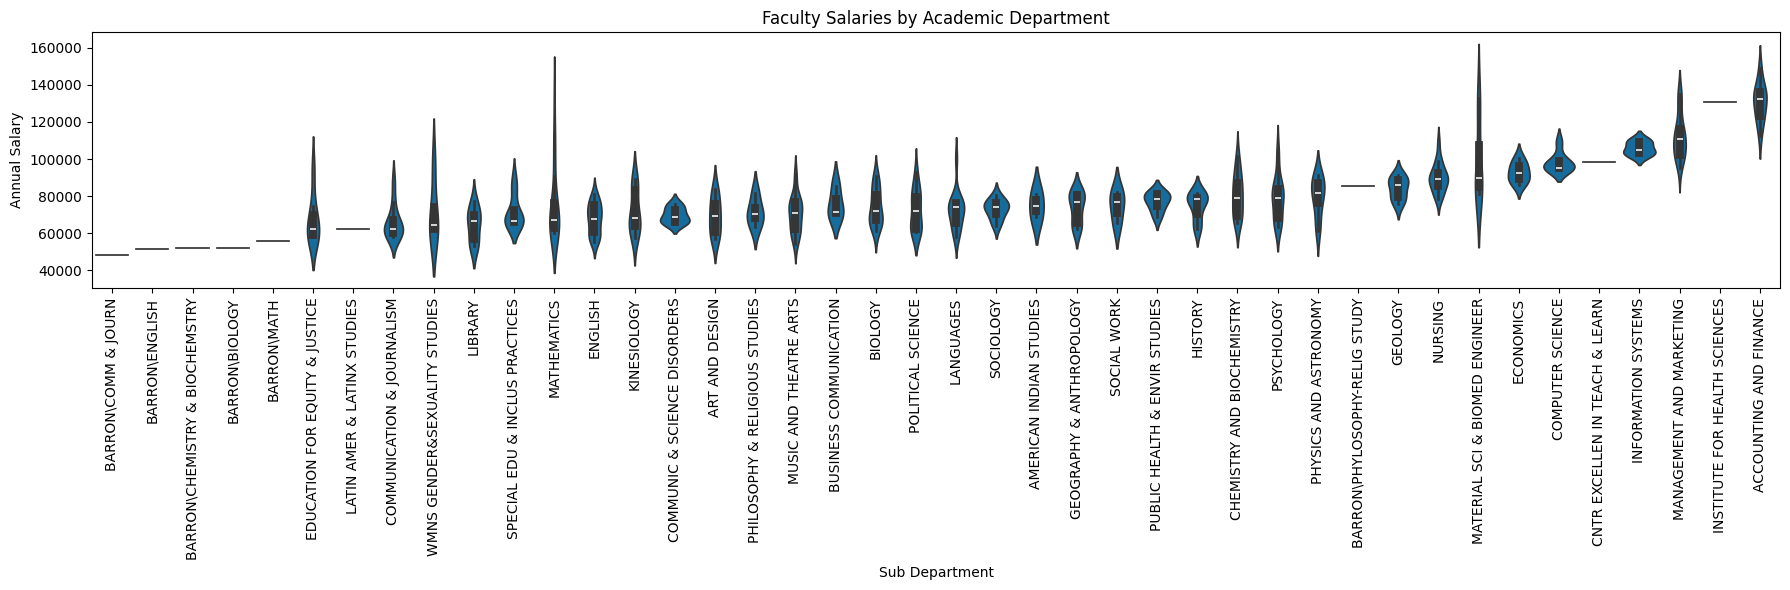

In [ ]:
# Subtask 1.4.2
plt.figure(figsize=(18, 6))

order = (
    salary_df[salary_df["Empl Class Code"] == "FA"]
    .groupby("Sub Department")["Annual Salary"]
    .median()
    .sort_values()
    .index
)

sns.violinplot(
    data=salary_df[salary_df['Empl Class Code']=='FA'],
    x="Sub Department",
    y="Annual Salary",
    color="#0072B2",
    order=order,
    legend=False
)
plt.xticks(rotation=90)
plt.title("Faculty Salaries by Academic Department")
plt.tight_layout()



'''Those changes—wider figure, sorted categories, rotated labels, 
and plt.tight_layout()—make the biggest difference in readability 
while keeping the plot uncluttered. If your assignment requires each department 
to have a different color, keep the hue, but otherwise a single color is generally
 easier to interpret.
'''

In [53]:
# Subtask 1.5: Stacked bars
pay_basis = salary_df.pivot(columns='Pay Basis')
pay_basis["Annual Salary"].head()

Pay Basis,A,C,H
0,NaN,NaN,57491.2
1,62000.0,NaN,NaN
2,100000.0,NaN,NaN
3,100444.0,NaN,NaN
4,144840.0,NaN,NaN


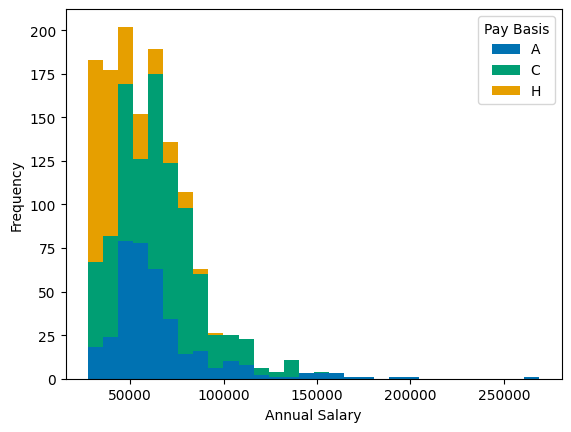

In [54]:
plt.hist(
    [
        pay_basis["Annual Salary"]["A"].dropna(),
        pay_basis["Annual Salary"]["C"].dropna(),
        pay_basis["Annual Salary"]["H"].dropna()
    ],
    bins=30,
    stacked=True,
    label=["A", "C", "H"],
    color=[
        "#0072B2",  # Blue
        "#009E73",  # Bluish Green
        "#E69F00"   # Orange
    ]
)
plt.xlabel("Annual Salary")
plt.ylabel("Frequency")
plt.legend(title="Pay Basis")

In [55]:
# Task 2: Housing Data
# Subtask 2.1: Load the data
housing_master_df = pd.read_csv("HPI_master.csv")

# Make a new variable housing_df, containing only the records in the set for which
#  the "level" is "MSA", and "hpi_flavor" is "all-transactions".
housing_df = housing_master_df[
    (housing_master_df["level"] == "MSA")
    & (housing_master_df["hpi_flavor"] == "all-transactions")
]


In [56]:
housing_df.head()

,hpi_type,hpi_flavor,frequency,level,place_name,place_id,yr,period,index_nsa,index_sa
3770,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180,1986,2,107.53,NaN
3771,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180,1986,3,107.55,NaN
3772,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180,1986,4,94.27,NaN
3773,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180,1987,1,100.67,NaN
3774,traditional,all-transactions,quarterly,MSA,"Abilene, TX",10180,1987,2,100.46,NaN


In [69]:
def plot_price_for_places(df: pd.DataFrame, places: list) -> tuple:
    matching = df[
        df["place_name"].isin(places)
    ]  # filter dataframe to only places in list
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.lineplot(
        data=matching,
        x=matching["yr"] + 0.25 * matching["period"],
        y="index_nsa",
        hue="place_name",
        ax=ax,
        errorbar=None,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Price (HPI)")
    ax.legend(title="Place")
    return (fig, ax)

C:\Users\benbr\AppData\Local\Temp\ipykernel_38868\2833063650.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


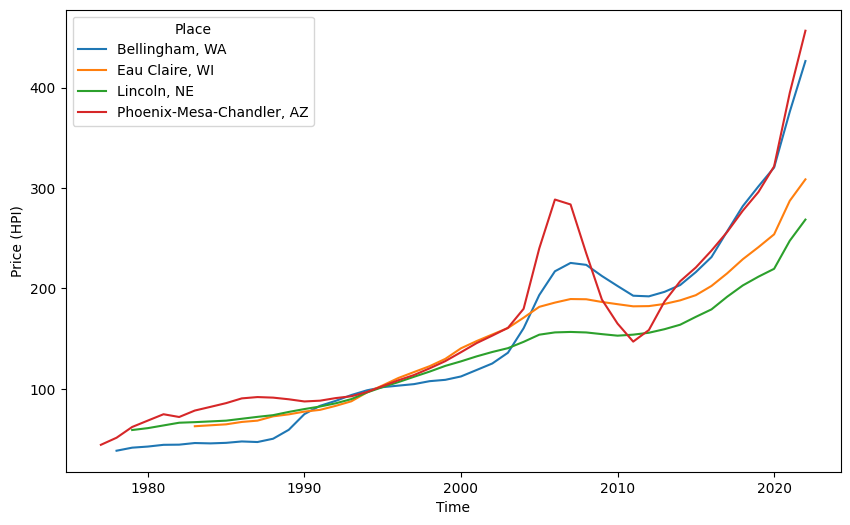

In [68]:
places = ['Eau Claire, WI','Lincoln, NE','Bellingham, WA','Phoenix-Mesa-Chandler, AZ']
plot_price_for_places(housing_df, places)
plt.savefig(f'{last_name}_{first_name}_assign6b_task2-2-WI.png', dpi=300, bbox_inches="tight")

In [77]:
# Subtask 2.3
def plot_price_hist(df: pd.DataFrame, t1: tuple, t2: tuple):
    year_1, period_1 = t1
    year_2, period_2 = t2

    # Filter to each time point
    data_t1 = df[(df['yr'] == year_1) & (df['period'] == period_1)]['index_nsa'].dropna()
    data_t2 = df[(df['yr'] == year_2) & (df['period'] == period_2)]['index_nsa'].dropna()

    # Fixed bin edges: width of 20, spanning 100–450
    bins = np.arange(100, 451, 20)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    ax1.hist(data_t1, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4)
    ax1.set_xlabel(f'[thousands of $], {year_1} q{period_1}')
    ax1.set_ylabel('Frequency')

    ax2.hist(data_t2, bins=bins, color='steelblue', edgecolor='white', linewidth=0.4)
    ax2.set_xlabel(f'[thousands of $], {year_2} q{period_2}')
    ax2.set_ylabel('Frequency')

    plt.tight_layout()
    return fig, (ax1, ax2)

(<Figure size 1000x400 with 2 Axes>,
 (<Axes: xlabel='[thousands of $], 2010 q1', ylabel='Frequency'>,
  <Axes: xlabel='[thousands of $], 2020 q1', ylabel='Frequency'>))

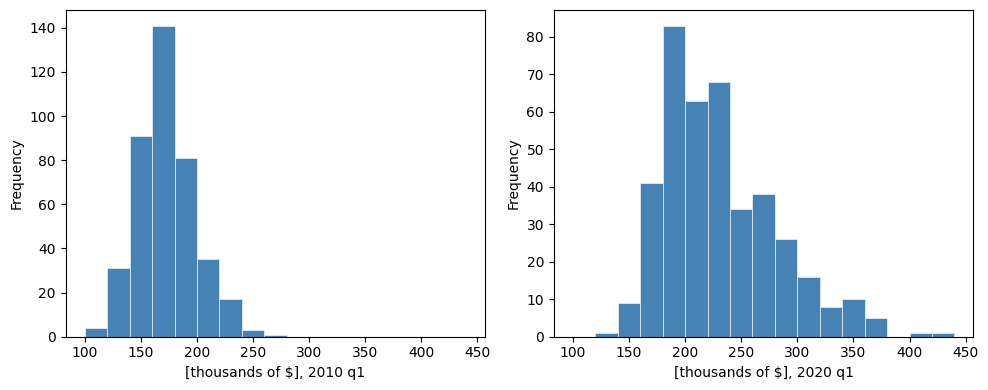

In [78]:
plot_price_hist(housing_df, (2010,1), (2020,1))

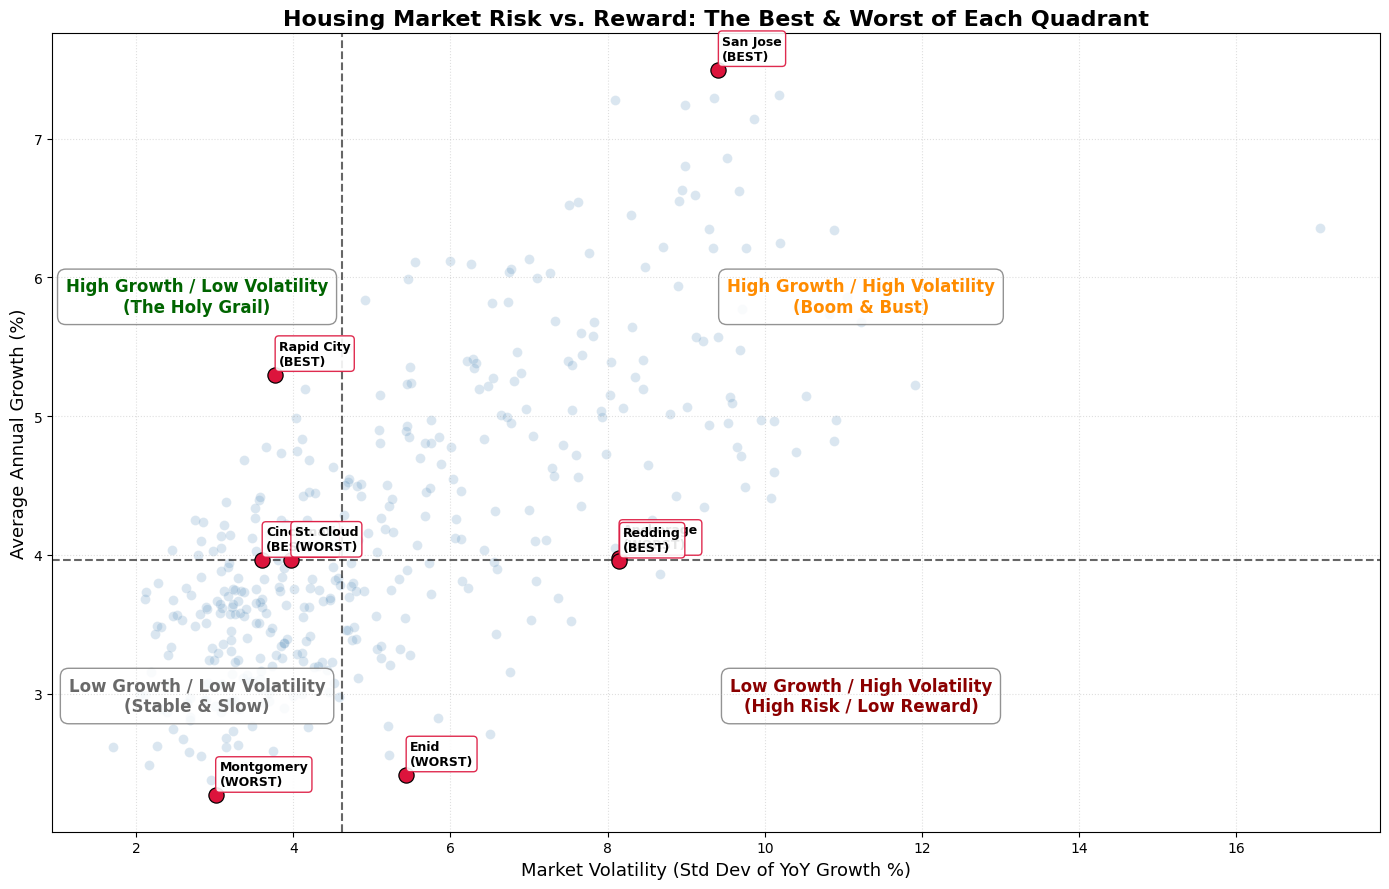

In [ ]:

# 2. Calculate YoY Growth and Volatility
annual_hpi = housing_df.groupby(['place_name', 'yr'])['index_nsa'].mean().reset_index()
annual_hpi = annual_hpi.sort_values(by=['place_name', 'yr'])
annual_hpi['yoy_change'] = annual_hpi.groupby('place_name')['index_nsa'].pct_change() * 100

summary_df = annual_hpi.groupby('place_name').agg(
    volatility=('yoy_change', 'std'),
    avg_growth=('yoy_change', 'mean')
).dropna().reset_index()

# 3. Calculate medians to draw quadrant boundaries
vol_median = summary_df['volatility'].median()
grw_median = summary_df['avg_growth'].median()

# 4. Function to assign each city to a quadrant
def assign_quadrant(row):
    if row['volatility'] <= vol_median and row['avg_growth'] > grw_median:
        return 'Holy Grail'
    elif row['volatility'] > vol_median and row['avg_growth'] > grw_median:
        return 'Boom & Bust'
    elif row['volatility'] <= vol_median and row['avg_growth'] <= grw_median:
        return 'Stable & Slow'
    else:
        return 'High Risk, Low Reward'

summary_df['quadrant'] = summary_df.apply(assign_quadrant, axis=1)

# 5. Dynamically isolate the Best and Worst in each quadrant
highlights = []
for quad in summary_df['quadrant'].unique():
    quad_df = summary_df[summary_df['quadrant'] == quad]
    
    # Best: Max Growth. Worst: Min Growth.
    best_idx = quad_df['avg_growth'].idxmax()
    worst_idx = quad_df['avg_growth'].idxmin()
    
    best_row = summary_df.loc[best_idx].copy()
    best_row['label'] = f"BEST"
    
    worst_row = summary_df.loc[worst_idx].copy()
    worst_row['label'] = f"WORST"
    
    highlights.extend([best_row, worst_row])

# Drop duplicates just in case one point is both best and worst (rare, but possible in tiny datasets)
highlight_df = pd.DataFrame(highlights).drop_duplicates(subset=['place_name'])

# 6. Create the Plot
fig, ax = plt.subplots(figsize=(14, 9))

# Plot all background points lightly
sns.scatterplot(data=summary_df, x='volatility', y='avg_growth', alpha=0.2, color='steelblue', s=50, ax=ax)

# Plot the 8 Best/Worst points prominently
sns.scatterplot(data=highlight_df, x='volatility', y='avg_growth', color='crimson', s=120, edgecolor='black', zorder=5, ax=ax)

# 7. Annotate the Best/Worst points
for _, row in highlight_df.iterrows():
    # Clean the MSA string to grab just the primary city name
    short_name = row['place_name'].split(',')[0].split('-')[0]
    label_text = f"{short_name}\n({row['label']})"
    
    # Add slight offsets so the text doesn't block the dot
    x_offset = 0.05
    y_offset = 0.05
    
    ax.text(row['volatility'] + x_offset, row['avg_growth'] + y_offset, label_text, 
            fontsize=9, ha='left', va='bottom', weight='bold', 
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="crimson", alpha=0.9), zorder=10)

# 8. Draw Quadrant Lines
ax.axvline(vol_median, color='black', linestyle='--', alpha=0.6)
ax.axhline(grw_median, color='black', linestyle='--', alpha=0.6)

# 1. Get the current boundaries of the graph
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# 2. Calculate the exact center coordinates for each of the four quadrants
left_center_x = xlim[0] + (vol_median - xlim[0]) * 0.5
right_center_x = vol_median + (xlim[1] - vol_median) * 0.5
bottom_center_y = ylim[0] + (grw_median - ylim[0]) * 0.5
top_center_y = grw_median + (ylim[1] - grw_median) * 0.5

# 3. Create a styling dictionary for a background box so the text is readable
bbox_style = dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.85)

# 4. Place the text in each quadrant
# Top-Left
ax.text(left_center_x, top_center_y, "High Growth / Low Volatility\n(The Holy Grail)", 
        ha="center", va="center", fontsize=12, weight="bold", color="darkgreen", bbox=bbox_style, zorder=1)

# Top-Right
ax.text(right_center_x, top_center_y, "High Growth / High Volatility\n(Boom & Bust)", 
        ha="center", va="center", fontsize=12, weight="bold", color="darkorange", bbox=bbox_style, zorder=1)

# Bottom-Left
ax.text(left_center_x, bottom_center_y, "Low Growth / Low Volatility\n(Stable & Slow)", 
        ha="center", va="center", fontsize=12, weight="bold", color="dimgray", bbox=bbox_style, zorder=1)

# Bottom-Right
ax.text(right_center_x, bottom_center_y, "Low Growth / High Volatility\n(High Risk / Low Reward)", 
        ha="center", va="center", fontsize=12, weight="bold", color="darkred", bbox=bbox_style, zorder=1)

plt.title("Housing Market Risk vs. Reward: The Best & Worst of Each Quadrant", fontsize=16, weight='bold')
plt.xlabel("Market Volatility (Std Dev of YoY Growth %)", fontsize=13)
plt.ylabel("Average Annual Growth (%)", fontsize=13)
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()


C:\Users\benbr\AppData\Local\Temp\ipykernel_38868\3405565933.py:205: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\benbr\AppData\Local\Temp\ipykernel_38868\3405565933.py:211: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(output_path, dpi=150, bbox_inches="tight")


Figure saved to: risk_reward_scatter.png


c:\Users\benbr\anaconda3\envs\ds710\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


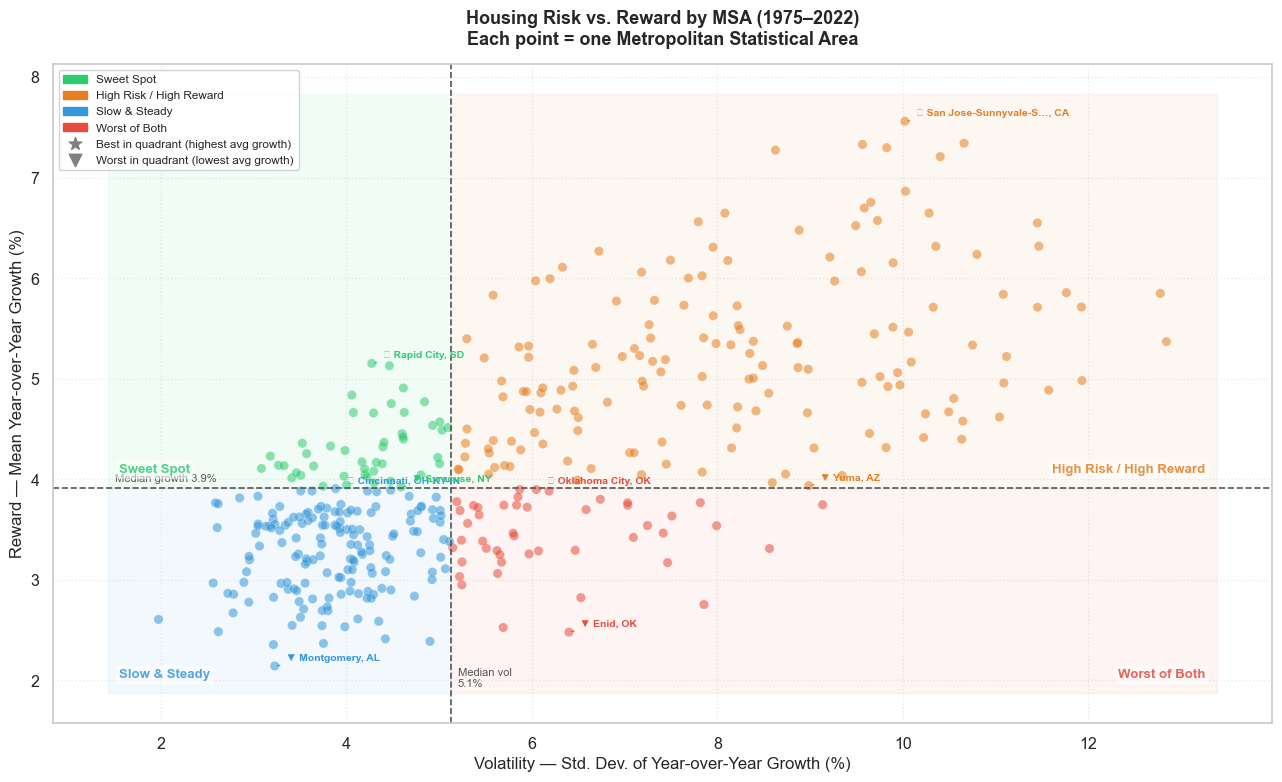

In [81]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# ---------------------------------------------------------------------------
# 2. Compute Year-over-Year (YoY) growth per MSA
#    Shift within the same quarter (period) to avoid seasonal distortion:
#    e.g. Q1 2020 is compared to Q1 2019, not Q4 2019.
# ---------------------------------------------------------------------------
housing_df = housing_df.sort_values(["place_name", "yr", "period"])

housing_df["index_lag"] = housing_df.groupby(["place_name", "period"])[
    "index_nsa"
].shift(1)

housing_df["yoy_growth"] = (
    (housing_df["index_nsa"] - housing_df["index_lag"])
    / housing_df["index_lag"]
    * 100
)

# ---------------------------------------------------------------------------
# 3. Per-MSA risk / reward summary
#    - Reward  = mean YoY growth over the full history
#    - Risk    = standard deviation of YoY growth (volatility)
#    Require >= 20 YoY observations so sparse MSAs don't skew results.
# ---------------------------------------------------------------------------
stats = (
    housing_df.groupby("place_name")["yoy_growth"]
    .agg(avg_yoy="mean", std_yoy="std", count="count")
    .dropna()
)
stats = stats[stats["count"] >= 20].copy()

# ---------------------------------------------------------------------------
# 4. Assign each MSA to a quadrant
#    Boundaries are the medians — more robust to outliers than the mean.
#
#    Quadrant layout:
#      HIGH growth / LOW  vol  →  Sweet Spot              (top-left)
#      HIGH growth / HIGH vol  →  High Risk / High Reward (top-right)
#      LOW  growth / LOW  vol  →  Slow & Steady           (bottom-left)
#      LOW  growth / HIGH vol  →  Worst of Both           (bottom-right)
# ---------------------------------------------------------------------------
med_x = stats["std_yoy"].median()   # volatility split
med_y = stats["avg_yoy"].median()   # growth split

quad_map = {
    (True,  True):  "Sweet Spot",
    (True,  False): "High Risk / High Reward",
    (False, True):  "Slow & Steady",
    (False, False): "Worst of Both",
}

stats["quadrant"] = stats.apply(
    lambda r: quad_map[(r["avg_yoy"] >= med_y, r["std_yoy"] < med_x)],
    axis=1,
)

# ---------------------------------------------------------------------------
# 5. Visual settings
# ---------------------------------------------------------------------------
quad_palette = {
    "Sweet Spot":              "#2ecc71",   # green
    "High Risk / High Reward": "#e67e22",   # orange
    "Slow & Steady":           "#3498db",   # blue
    "Worst of Both":           "#e74c3c",   # red
}
quad_order = [
    "Sweet Spot",
    "High Risk / High Reward",
    "Slow & Steady",
    "Worst of Both",
]

# ---------------------------------------------------------------------------
# 6. Identify best (★) and worst (▼) MSA per quadrant by avg YoY growth
# ---------------------------------------------------------------------------
label_rows = []
for q, grp in stats.groupby("quadrant"):
    label_rows.append((grp.loc[grp["avg_yoy"].idxmax()], q, "best"))
    label_rows.append((grp.loc[grp["avg_yoy"].idxmin()], q, "worst"))

# ---------------------------------------------------------------------------
# 7. Draw the plot
# ---------------------------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.05)
fig, ax = plt.subplots(figsize=(13, 8))

# -- Scatter: one point per MSA, coloured by quadrant --------------------
sns.scatterplot(
    data=stats,
    x="std_yoy",
    y="avg_yoy",
    hue="quadrant",
    hue_order=quad_order,
    palette=quad_palette,
    alpha=0.55,
    s=45,
    linewidth=0.3,
    edgecolor="white",
    ax=ax,
    legend=False,   # custom legend built below
)

# -- Quadrant divider lines ----------------------------------------------
ax.axvline(med_x, color="#555555", linewidth=1.2, linestyle="--", zorder=2)
ax.axhline(med_y, color="#555555", linewidth=1.2, linestyle="--", zorder=2)

# -- Shaded quadrant backgrounds -----------------------------------------
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

shade_alpha = 0.06
ax.fill_betweenx([med_y, ymax], xmin, med_x,  color=quad_palette["Sweet Spot"],             alpha=shade_alpha)
ax.fill_betweenx([med_y, ymax], med_x, xmax,  color=quad_palette["High Risk / High Reward"], alpha=shade_alpha)
ax.fill_betweenx([ymin, med_y], xmin, med_x,  color=quad_palette["Slow & Steady"],           alpha=shade_alpha)
ax.fill_betweenx([ymin, med_y], med_x, xmax,  color=quad_palette["Worst of Both"],           alpha=shade_alpha)

# -- Quadrant corner text labels -----------------------------------------
x_pad = (xmax - xmin) * 0.01
y_pad = (ymax - ymin) * 0.02

corner_positions = {
    "Sweet Spot":              (xmin + x_pad, med_y + y_pad, "left",  "bottom"),
    "High Risk / High Reward": (xmax - x_pad, med_y + y_pad, "right", "bottom"),
    "Slow & Steady":           (xmin + x_pad, ymin + y_pad,  "left",  "bottom"),
    "Worst of Both":           (xmax - x_pad, ymin + y_pad,  "right", "bottom"),
}
for q, (x, y, ha, va) in corner_positions.items():
    ax.text(
        x, y, q,
        color=quad_palette[q], fontsize=9.5, fontweight="bold",
        ha=ha, va=va, alpha=0.85, zorder=4,
        bbox=dict(boxstyle="round,pad=0.25", fc="white", alpha=0.55, ec="none"),
    )

# -- Median crosshair labels ---------------------------------------------
ax.text(
    med_x + 0.07, ymin + 0.04,
    f"Median vol\n{med_x:.1f}%",
    fontsize=8, color="#555555", va="bottom",
)
ax.text(
    xmin + 0.07, med_y + 0.04,
    f"Median growth {med_y:.1f}%",
    fontsize=8, color="#555555", va="bottom",
)

# -- Annotate best & worst MSA per quadrant ------------------------------
already_labeled = set()
for row, q, kind in label_rows:
    name = row.name
    if name in already_labeled:
        continue
    already_labeled.add(name)

    city  = name.split(",")[0]
    state = name.split(",")[1].strip().split(" ")[0] if "," in name else ""
    short = city[:20] + "…" if len(city) > 22 else city
    marker = "★" if kind == "best" else "▼"

    ax.annotate(
        f"{marker} {short}, {state}",
        xy=(row["std_yoy"], row["avg_yoy"]),
        xytext=(8, 4),
        textcoords="offset points",
        fontsize=7.5,
        color=quad_palette[q],
        fontweight="bold",
        arrowprops=dict(arrowstyle="-", color=quad_palette[q], lw=0.8),
        zorder=5,
    )

# -- Custom legend -------------------------------------------------------
quad_handles = [
    mpatches.Patch(color=quad_palette[q], label=q) for q in quad_order
]
marker_handles = [
    Line2D([0], [0], marker="$★$", color="gray", markersize=9,
           linestyle="None", label="Best in quadrant (highest avg growth)"),
    Line2D([0], [0], marker="$▼$", color="gray", markersize=9,
           linestyle="None", label="Worst in quadrant (lowest avg growth)"),
]
ax.legend(
    handles=quad_handles + marker_handles,
    loc="upper left",
    fontsize=8.5,
    framealpha=0.85,
)

# -- Axis labels & title -------------------------------------------------
ax.set_xlabel("Volatility — Std. Dev. of Year-over-Year Growth (%)", fontsize=12)
ax.set_ylabel("Reward — Mean Year-over-Year Growth (%)", fontsize=12)
ax.set_title(
    "Housing Risk vs. Reward by MSA (1975–2022)\n"
    "Each point = one Metropolitan Statistical Area",
    fontsize=13, fontweight="bold", pad=14,
)

ax.grid(True, linestyle=":", alpha=0.4, zorder=1)
plt.tight_layout()

# ---------------------------------------------------------------------------
# 8. Save
# ---------------------------------------------------------------------------
output_path = "risk_reward_scatter.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Figure saved to: {output_path}")